In [88]:
import pandas as pd

# Load the dataset
file_path = "converted.csv"  # Change path if needed
df = pd.read_csv(file_path)

# Display basic information about the dataset
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Cost Rank  20 non-null     int64  
 1   FY22 Q2    14 non-null     float64
 2   FY22 Q3    14 non-null     float64
 3   FY22 Q4    17 non-null     float64
 4   FY23 Q1    17 non-null     float64
 5   FY23 Q2    18 non-null     float64
 6   FY23 Q3    20 non-null     int64  
 7   FY23 Q4    20 non-null     int64  
 8   FY24 Q1    20 non-null     int64  
 9   FY24 Q2    20 non-null     int64  
 10  FY24 Q3    20 non-null     int64  
 11  FY24 Q4    20 non-null     int64  
 12  FY25 Q1    20 non-null     int64  
dtypes: float64(5), int64(8)
memory usage: 2.2 KB


,Cost Rank,FY22 Q2,FY22 Q3,FY22 Q4,FY23 Q1,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,FY25 Q1
0,1,57147.0,52873.0,52870.0,38833.0,27114.0,21823,31813,27302,22084,21830,29404,24518
1,2,222.0,1549.0,4619.0,4764.0,5015.0,6656,9605,5956,8450,8584,12552,9665
2,3,24362.0,21308.0,19067.0,14551.0,13271.0,10165,10477,7295,8084,9249,10742,9189
3,4,NaN,NaN,1227.0,24186.0,7680.0,16772,17554,16095,26125,24337,21988,32768
4,5,208760.0,116126.0,150803.0,82163.0,82408.0,67132,87498,69599,78130,76840,85421,54494


/tmp/ipykernel_17291/627836046.py:8: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarters = pd.date_range(start="2022-07-01", periods=len(df_ts), freq="Q")


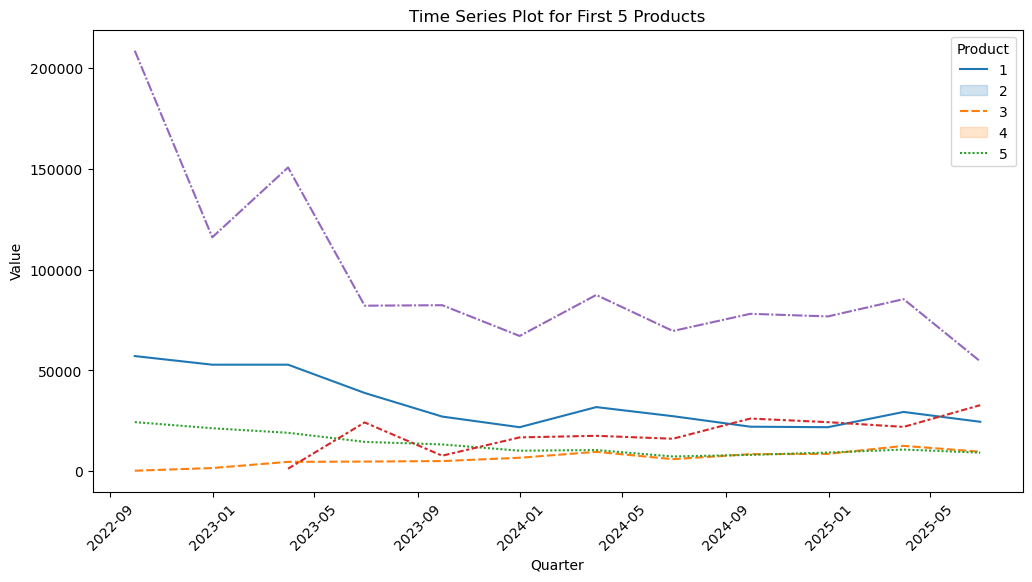

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Transpose the dataset to make it a time series
df_ts = df.set_index("Cost Rank").T

# Convert the index to datetime format (assuming quarters)
quarters = pd.date_range(start="2022-07-01", periods=len(df_ts), freq="Q")
df_ts.index = quarters

# Plot the time series for a few products
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_ts.iloc[:, :5])  # Plot first 5 products
plt.xlabel("Quarter")
plt.ylabel("Value")
plt.title("Time Series Plot for First 5 Products")
plt.xticks(rotation=45)
plt.legend(df_ts.columns[:5], title="Product")
plt.show()


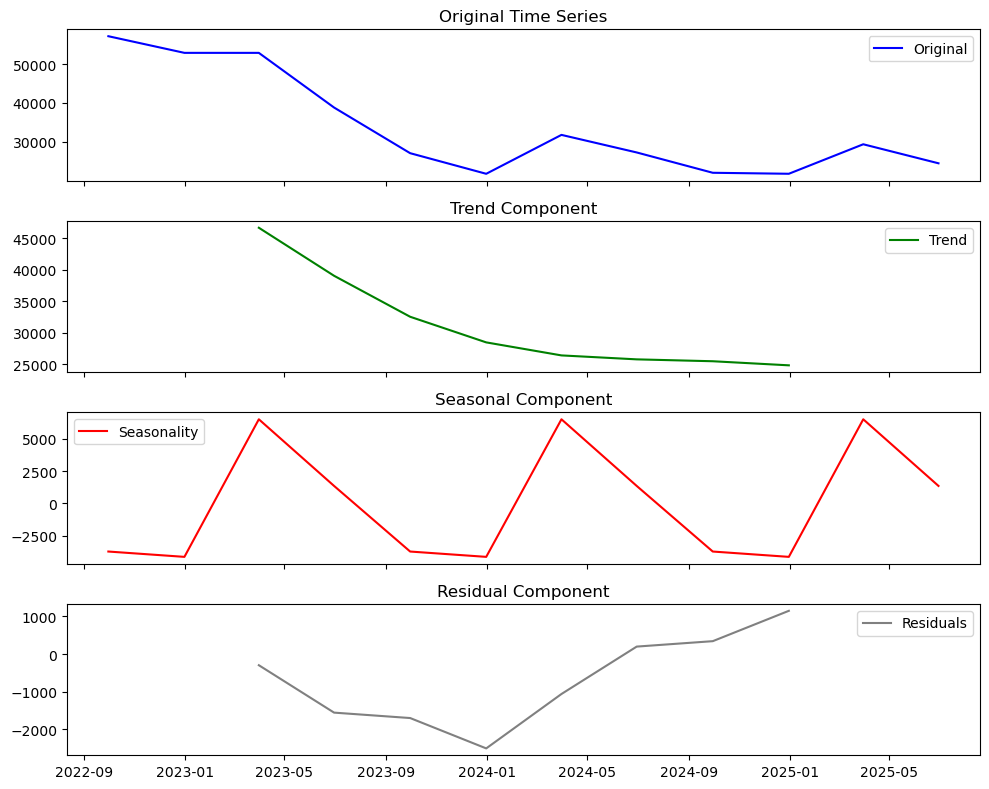

In [106]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition on the first product's time series
product_1_series = df_ts.iloc[:, 0]  # Selecting the first product

# Decompose the time series
decomposition = seasonal_decompose(product_1_series, model="additive", period=4)  # Quarterly data

# Plot decomposition components
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axes[0].plot(product_1_series, label="Original", color="blue")
axes[0].set_title("Original Time Series")
axes[0].legend()

axes[1].plot(decomposition.trend, label="Trend", color="green")
axes[1].set_title("Trend Component")
axes[1].legend()

axes[2].plot(decomposition.seasonal, label="Seasonality", color="red")
axes[2].set_title("Seasonal Component")
axes[2].legend()

axes[3].plot(decomposition.resid, label="Residuals", color="gray")
axes[3].set_title("Residual Component")
axes[3].legend()

plt.tight_layout()
plt.show()


<Figure size 800x400 with 0 Axes>

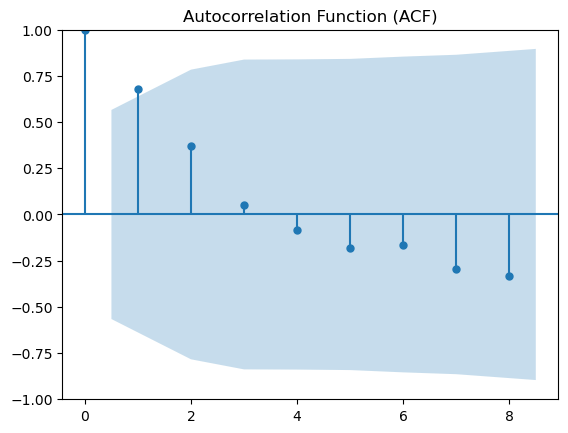

,lb_stat,lb_pvalue
4,9.534901,0.049035


In [108]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# Perform the Ljung-Box test for autocorrelation (lags=4 for quarterly data)
ljung_box_result = acorr_ljungbox(product_1_series.dropna(), lags=[4], return_df=True)

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 4))
plot_acf(product_1_series.dropna(), lags=8)
plt.title("Autocorrelation Function (ACF)")
plt.show()

# Display Ljung-Box test result
ljung_box_result


In [110]:
!pip install pmdarima statsmodels


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 2.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 1.4 MB/s eta 0:00:00a 0:00:01


In [112]:
# Fill missing values using linear interpolation
df_ts_filled = df_ts.interpolate(method='linear')

# Verify if all missing values are handled
df_ts_filled.isnull().sum()


Cost Rank
1     0
2     0
3     0
4     2
5     0
6     0
7     0
8     2
9     0
10    5
11    5
12    0
13    2
14    0
15    0
16    0
17    0
18    0
19    0
20    4
dtype: int64

In [114]:
df_ts_filled.head()

Cost Rank,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
2022-09-30,57147.0,222.0,24362.0,NaN,208760.0,204604.0,19790.0,NaN,191286.0,NaN,NaN,1263.0,NaN,2057.0,58911.0,2349.0,4593.0,13153.0,6629.0,NaN
2022-12-31,52873.0,1549.0,21308.0,NaN,116126.0,194538.0,2476.0,NaN,228892.0,NaN,NaN,1314.0,NaN,4266.0,69308.0,2359.0,6513.0,15149.0,4275.0,NaN
2023-03-31,52870.0,4619.0,19067.0,1227.0,150803.0,185160.0,3149.0,13260.0,197489.0,NaN,NaN,843.0,1688.0,11650.0,107690.0,2861.0,3093.0,17700.0,2981.0,NaN
2023-06-30,38833.0,4764.0,14551.0,24186.0,82163.0,147284.0,6367.0,21667.0,138040.0,NaN,NaN,974.0,531.0,7218.0,70616.0,2655.0,2531.0,10373.0,2956.0,NaN
2023-09-30,27114.0,5015.0,13271.0,7680.0,82408.0,136997.0,2287.0,30498.0,116870.0,NaN,NaN,753.0,6487.0,6969.0,68431.0,3497.0,2182.0,15770.0,1987.0,6.0


In [116]:
import pandas as pd

# Load the dataset
file_path = "converted.csv"  # Update the file path if necessary
df = pd.read_csv(file_path, parse_dates=["Cost Rank"], index_col="Cost Rank")

# Display first few rows
df.head()


/tmp/ipykernel_17291/3065675630.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file_path, parse_dates=["Cost Rank"], index_col="Cost Rank")


,FY22 Q2,FY22 Q3,FY22 Q4,FY23 Q1,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,FY25 Q1
Cost Rank,,,,,,,,,,,,
1,57147.0,52873.0,52870.0,38833.0,27114.0,21823,31813,27302,22084,21830,29404,24518
2,222.0,1549.0,4619.0,4764.0,5015.0,6656,9605,5956,8450,8584,12552,9665
3,24362.0,21308.0,19067.0,14551.0,13271.0,10165,10477,7295,8084,9249,10742,9189
4,NaN,NaN,1227.0,24186.0,7680.0,16772,17554,16095,26125,24337,21988,32768
5,208760.0,116126.0,150803.0,82163.0,82408.0,67132,87498,69599,78130,76840,85421,54494


In [118]:
# Fill missing values using linear interpolation
df_filled = df.interpolate(method='linear')

# Check if all missing values are handled
df_filled.isnull().sum()


FY22 Q2    0
FY22 Q3    0
FY22 Q4    0
FY23 Q1    0
FY23 Q2    0
FY23 Q3    0
FY23 Q4    0
FY24 Q1    0
FY24 Q2    0
FY24 Q3    0
FY24 Q4    0
FY25 Q1    0
dtype: int64

In [120]:
df_filled.head()

,FY22 Q2,FY22 Q3,FY22 Q4,FY23 Q1,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,FY25 Q1
Cost Rank,,,,,,,,,,,,
1,57147.0,52873.0,52870.0,38833.0,27114.0,21823,31813,27302,22084,21830,29404,24518
2,222.0,1549.0,4619.0,4764.0,5015.0,6656,9605,5956,8450,8584,12552,9665
3,24362.0,21308.0,19067.0,14551.0,13271.0,10165,10477,7295,8084,9249,10742,9189
4,116561.0,68717.0,1227.0,24186.0,7680.0,16772,17554,16095,26125,24337,21988,32768
5,208760.0,116126.0,150803.0,82163.0,82408.0,67132,87498,69599,78130,76840,85421,54494


In [122]:
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Select a product for forecasting (e.g., Cost Rank 1)
product_series = df_filled.iloc[:, 0]  # First product

# Automatically determine the best SARIMA parameters
auto_model = auto_arima(product_series, 
                        seasonal=True, 
                        m=4,   # Quarterly data (seasonal period = 4)
                        trace=True, 
                        suppress_warnings=True)

# Print the best SARIMA order
print(auto_model.order, auto_model.seasonal_order)


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[4] intercept   : AIC=inf, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[4] intercept   : AIC=507.638, Time=0.00 sec
 ARIMA(1,0,0)(1,0,0)[4] intercept   : AIC=503.845, Time=0.01 sec
 ARIMA(0,0,1)(0,0,1)[4] intercept   : AIC=501.488, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[4]             : AIC=516.640, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[4] intercept   : AIC=500.883, Time=0.01 sec
 ARIMA(0,0,1)(1,0,0)[4] intercept   : AIC=502.297, Time=0.01 sec
 ARIMA(0,0,1)(1,0,1)[4] intercept   : AIC=503.191, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[4] intercept   : AIC=502.301, Time=0.01 sec
 ARIMA(0,0,2)(0,0,0)[4] intercept   : AIC=502.779, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[4] intercept   : AIC=502.592, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[4] intercept   : AIC=inf, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[4]             : AIC=506.211, Time=0.01 sec

Best model:  ARIMA(0,0,1)(0,0,0)[4] intercept
Total fit time: 0.241 seconds
(0, 0, 1) (0, 0, 0, 4)


In [124]:
# Fit the best SARIMA model
best_order = auto_model.order
best_seasonal_order = auto_model.seasonal_order

sarima_model = SARIMAX(product_series, 
                        order=best_order, 
                        seasonal_order=best_seasonal_order, 
                        enforce_stationarity=False, 
                        enforce_invertibility=False).fit()

# Forecast the next quarter (FY25 Q2)
forecast_steps = 1  # Predict one step ahead (FY25 Q2)
forecast = sarima_model.forecast(steps=forecast_steps)

# Display forecast result
print(f"Predicted value for FY25 Q2: {forecast.values[0]}")


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            2     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.13067D+01    |proj g|=  6.92891D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    2      4      7      1     0     0   3.046D-06   1.131D+01
  F =   11.305704980313122     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
Predicted value for FY25 Q2: -16843.281948768104


/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
 This problem is unconstrained.
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/s39dhi/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


/tmp/ipykernel_17291/4278653659.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df_filled.index[-1], periods=forecast_steps+1, freq="Q")[1:]


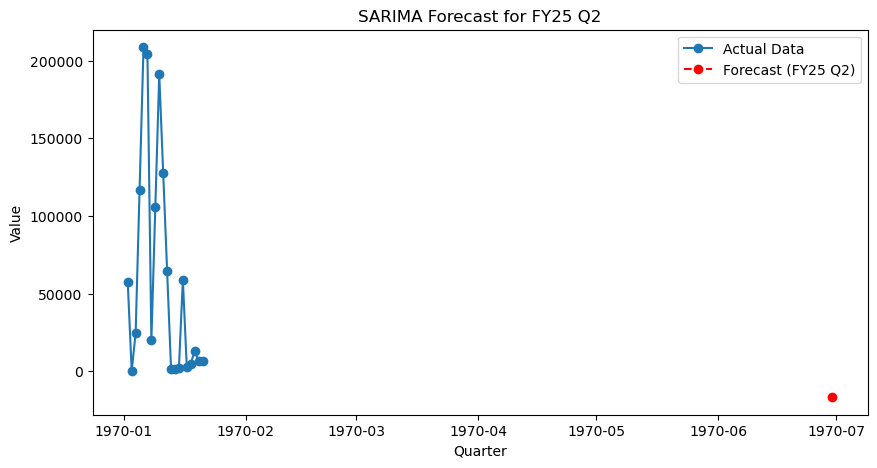

In [126]:
import matplotlib.pyplot as plt
import numpy as np

# Extend time index for forecasting
future_dates = pd.date_range(start=df_filled.index[-1], periods=forecast_steps+1, freq="Q")[1:]

# Plot historical data and forecast
plt.figure(figsize=(10, 5))
plt.plot(df_filled.index, product_series, label="Actual Data", marker="o")
plt.plot(future_dates, forecast, label="Forecast (FY25 Q2)", marker="o", linestyle="dashed", color="red")

plt.xlabel("Quarter")
plt.ylabel("Value")
plt.title("SARIMA Forecast for FY25 Q2")
plt.legend()
plt.show()


In [130]:
import pandas as pd

# Function to map fiscal quarters to real-world start dates
def convert_fy_quarter(fy_quarter):
    fy_quarter = str(fy_quarter)  # Ensure it's a string
    if "FY" not in fy_quarter or "Q" not in fy_quarter:
        raise ValueError(f"Invalid quarter format: {fy_quarter}")

    fy, q = fy_quarter.split(" ")  # Split into FY22 and Q2
    year = int(fy[2:]) + 2000  # Convert FY22 → 2022

    # Define custom fiscal start months & days
    quarter_start_dates = {
        "Q1": (7, 27),   # July 27
        "Q2": (10, 27),  # October 27
        "Q3": (1, 27),   # January 27 (next year shift needed)
        "Q4": (4, 27)    # April 27
    }

    if q not in quarter_start_dates:
        raise ValueError(f"Invalid quarter format: {fy_quarter}")

    month, day = quarter_start_dates[q]

    # Adjust year for Q3 (January) and Q4 (April)
    if q in ["Q3", "Q4"]:
        year += 1

    return pd.Timestamp(year=year, month=month, day=day)

# Load dataset
file_path = "converted.csv"  # Update file path if needed
df = pd.read_csv(file_path)

# Rename first column (which contains quarters)
df.rename(columns={"Cost Rank": "Quarter"}, inplace=True)

# Ensure column is a string before applying function
df["Quarter"] = df["Quarter"].astype(str)

# Convert fiscal quarters to real-world dates
df["Quarter"] = df["Quarter"].apply(convert_fy_quarter)

# Set as datetime index
df.set_index("Quarter", inplace=True)

# Ensure chronological order
df = df.sort_index()

# Display corrected dataset
df.head()


ValueError: Invalid quarter format: 1

In [132]:
print(df["Quarter"].unique())  # Debugging step


['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '20']


In [134]:
df["Quarter"] = df["Quarter"].astype(str)  # Ensure all values are strings
df["Quarter"] = df["Quarter"].apply(lambda x: f"FY{x[:2]} Q{x[-1]}" if x.isdigit() else x)


In [136]:
df["Quarter"] = df["Quarter"].astype(str)  # Ensure all values are strings
df["Quarter"] = df["Quarter"].apply(lambda x: f"FY{x[:2]} Q{x[-1]}" if x.isdigit() else x)


In [138]:
df["Quarter"] = df["Quarter"].apply(convert_fy_quarter)
df.set_index("Quarter", inplace=True)
df = df.sort_index()


ValueError: Invalid quarter format: FY5 Q5